In [1]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np

c_rate_formation = 20  # Assuming this is defined elsewhere
c_rate_cycling = 1/20     # Assuming this is defined elsewhere

formation_cycle = [
    (f"Charge at C/{c_rate_formation} until 4.2 V",
    "Hold at 4.2 V until C/200"),
    (f"Discharge at C/{c_rate_formation} until 2.5 V",
    "Hold at 2.5 V until C/200"),
]

cycling = [
    f"Charge at {c_rate_cycling}C until 4.2 V",
    f"Discharge at {c_rate_cycling}C until 2.5 V",
]

exp = pybamm.Experiment(
    ["Rest for 6 hour"] +
    formation_cycle * 2 +
    cycling * 3
)

# The SEI layer considered as one layer here, 
# so in all equations if there were Outer_or inner they have been removed
sei_options = [ "ec reaction limited", "ec reaction limited", "ec reaction limited",  "electron-migration limited",  "interstitial-diffusion limited", "tunnelling limited" , "Kolzenberg2020" ]
# sei_options = [ "ec reaction limited", "ec reaction limited",]
label_sei_options = ["RL", "DL", "Mixed", "EM", "ID", "ET", "VK"]  


k_sei =[ 7.0e-13, 1e-7, 1e-10, 1, 1, 7.0e-13, 1]
D_sol = [1e-14,1e-22, 0.8e-22, 1, 1, 1e-14, 1 ]
params = []
for i in range(0, len(k_sei)):
  param=pybamm.ParameterValues('Chen2020')
  param.update({
    'Initial inner SEI thickness [m]':5e-13,
    'Initial outer SEI thickness [m]':5e-13,
    'SEI kinetic rate constant [m.s-1]':k_sei[i],
    'Outer SEI solvent diffusivity [m2.s-1]':D_sol[i],
    'Bulk solvent concentration [mol.m-3]': 4541.0,
    'Inner SEI electron conductivity [S.m-1]': 8.95e-15, 
    'SEI lithium ion conductivity [S.m-1]': 1.0e-7, 
    'Inner SEI lithium interstitial diffusivity [m2.s-1]': 1e-20, 
    'Lithium interstitial reference concentration [mol.m-3]': 1000,
    }
              )
  params.append(param)
# setup pybamm model to includ SEI models as well
# models = [pybamm.lithium_ion.SPM({"particle": "uniform profile",
#                                   "SEI": sei_option}) for sei_option in sei_options]

models = [pybamm.lithium_ion.SPM({
                                  "SEI": sei_option}) for sei_option in sei_options]


solver = pybamm.CasadiSolver(mode="safe", extra_options_setup={"max_num_steps": 10000})

sims = [pybamm.Simulation(model, parameter_values=params[index],
                          experiment=exp, solver=solver) for index, model in enumerate(models)]
sols = [sim.solve(initial_soc=0) for sim in sims]


/home/kawamanmi/.local/lib/python3.11/site-packages/IPython/core/magics/osm.py:417: UserWarning: This is now an optional IPython functionality, setting dhist requires you to install the `pickleshare` library.
  self.shell.db['dhist'] = compress_dhist(dhist)[-100:]


/home/kawamanmi/Projects/PyBaMM


In [2]:
import pandas as pd
import matplotlib.pyplot as plt
%cd /home/kawamanmi/Projects/formation/comparison_SEI_zero_models
df_formation = pd.read_csv("experimental/FC_05_formation_0.csv")
df_cycles= pd.read_csv("experimental/FC_05_cycling_1.csv")

mode_diff = df_formation["mode"].diff()
index_switch = mode_diff[mode_diff != 0].index.to_list()
index_switch_formation = [0] + [i -1 for i in index_switch[1:]] + [len(df_formation["mode"])-1]


mode_diff = df_cycles["mode"].diff()
index_switch = mode_diff[mode_diff != 0].index.to_list()
index_switch_cycles = [0] + [i -1 for i in index_switch[1:]] + [len(df_cycles["mode"])-1]

# Specify which cycle you want to include up to (e.g., up to the 3rd cycle)
cycle_limit = 15  # Change this to include more or fewer cycles

# Get the index for the end of the specified cycle
end_index = index_switch_cycles[cycle_limit] if cycle_limit < len(index_switch_cycles) else index_switch_cycles[-1]

# Slice df_cycles up to the specified cycle
df_cycles_limited = df_cycles.iloc[:end_index + 1]

# Combine df_formation and the limited df_cycles
df_combined = pd.concat([df_formation, df_cycles_limited])

# plt.plot(df_cycles["time/s"]/3600, df_cycles["Ecell/V"])


A_cell = np.pi * 1.48 ** 2 / 4
# capacity first charge
capacity_1ch = (df_formation["(Q-Qo)/mA.h"].iloc[index_switch_formation[2]] - df_formation["(Q-Qo)/mA.h"].iloc[index_switch_formation[0]]) / A_cell

# capacity first discharge
capacity_1dch = (df_formation["(Q-Qo)/mA.h"].iloc[index_switch_formation[3]] - df_formation["(Q-Qo)/mA.h"].iloc[index_switch_formation[4]]) / A_cell

# capacity second charge
capacity_2ch = (df_formation["(Q-Qo)/mA.h"].iloc[index_switch_formation[7]] - df_formation
                
                ["(Q-Qo)/mA.h"].iloc[index_switch_formation[5]]) / A_cell
# capacity second discharge
capacity_2dch = (df_formation["(Q-Qo)/mA.h"].iloc[index_switch_formation[8]] - df_formation["(Q-Qo)/mA.h"].iloc[index_switch_formation[9]]) / A_cell

# capacity third charge
capacity_3ch = (df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[2]] - df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[0]]) / A_cell

# capacity third discharge
capacity_3dch = (df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[3]] - df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[4]]) / A_cell

# capacity fourth charge
capacity_4ch = (df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[7]] - df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[5]]) / A_cell

# capacity fourth discharge
capacity_4dch = (df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[8]] - df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[9]]) / A_cell

# capacity fifth charge
capacity_5ch = (df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[12]] - df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[10]]) / A_cell

# capacity fifth discharge
capacity_5dch = (df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[13]] - df_cycles["(Q-Qo)/mA.h"].iloc[index_switch_cycles[14]]) / A_cell

# Coulombic_efficiency_exp = []
# print("Charge capacity cycle 1:", capacity_1ch)
# print("Discharge capacity cycle 1:", capacity_1dch)
# print("Charge capacity cycle 2:", capacity_2ch)
# print("Discharge capacity cycle 2:", capacity_2dch)

# # Coulombic efficiency: discharge capacity / charge capacity
# print("Coulombic efficiency cycle 1:", capacity_1dch / capacity_1ch)
# print("Coulombic efficiency cycle 2:", capacity_2dch / capacity_2ch)


# print("Charge capacity cycle 3:", capacity_3ch)
# print("Disharge capacity cycle 3:", capacity_3dch)
# print("Charge capacity cycle 4:", capacity_4ch)
# print("Discharge capacity cycle 4:", capacity_4dch)
# print("Charge capacity cycle 5:", capacity_5ch)
# print("Discharge capacity cycle 5:", capacity_5dch)

# # Coulombic efficiency: discharge capacity / charge capacity
# print("Coulombic efficiency cycle 3:", capacity_3dch / capacity_3ch)
# print("Coulombic efficiency cycle 4:", capacity_4dch / capacity_4ch)
# print("Coulombic efficiency cycle 5:", capacity_5dch / capacity_5ch)


coulombic_efficiency_exp = np.array([capacity_1dch / capacity_1ch, capacity_2dch / capacity_2ch, capacity_3dch / capacity_3ch, capacity_4dch / capacity_4ch, capacity_5dch / capacity_5ch])
coulombic_efficiency_exp = (1- coulombic_efficiency_exp)*100
# print((1- coulombic_efficiency_exp)*100)

/home/kawamanmi/Projects/formation/comparison_SEI_zero_models


In [3]:
# %cd -
%cd /home/kawamanmi/Projects/formation/comparison_SEI_zero_models
import numpy as np

# First subplot
start_cycle = 2  # or whatever cycle number you want to start from
dch_cacpacity= []
ch_cacpacity= []

all_coulombic_efficiencies=[]
for index, model in enumerate(models):
    Coulombic_efficiency_model =[]
    for cycle_index in range(start_cycle - 1, len(sols[index].cycles)-1, 2):
        time_ch = sols[index].cycles[cycle_index]["Time [s]"].entries 
        time_dch = sols[index].cycles[cycle_index + 1]["Time [s]"].entries
        ch_cacpacity = sols[index].cycles[cycle_index]['Discharge capacity [A.h]'](time_ch[-1]) 
        dch_cacpacity = sols[index].cycles[cycle_index + 1]['Discharge capacity [A.h]'](time_dch[-1]) 
        Coulombic_efficiency_model.append((1- abs(dch_cacpacity/ch_cacpacity))*100)
    all_coulombic_efficiencies.append(Coulombic_efficiency_model)

all_coulombic_efficiencies.append(coulombic_efficiency_exp)
# print(np.shape(all_coulombic_efficiencies))


/home/kawamanmi/Projects/formation/comparison_SEI_zero_models


/home/kawamanmi/Projects/formation/comparison_SEI_zero_models


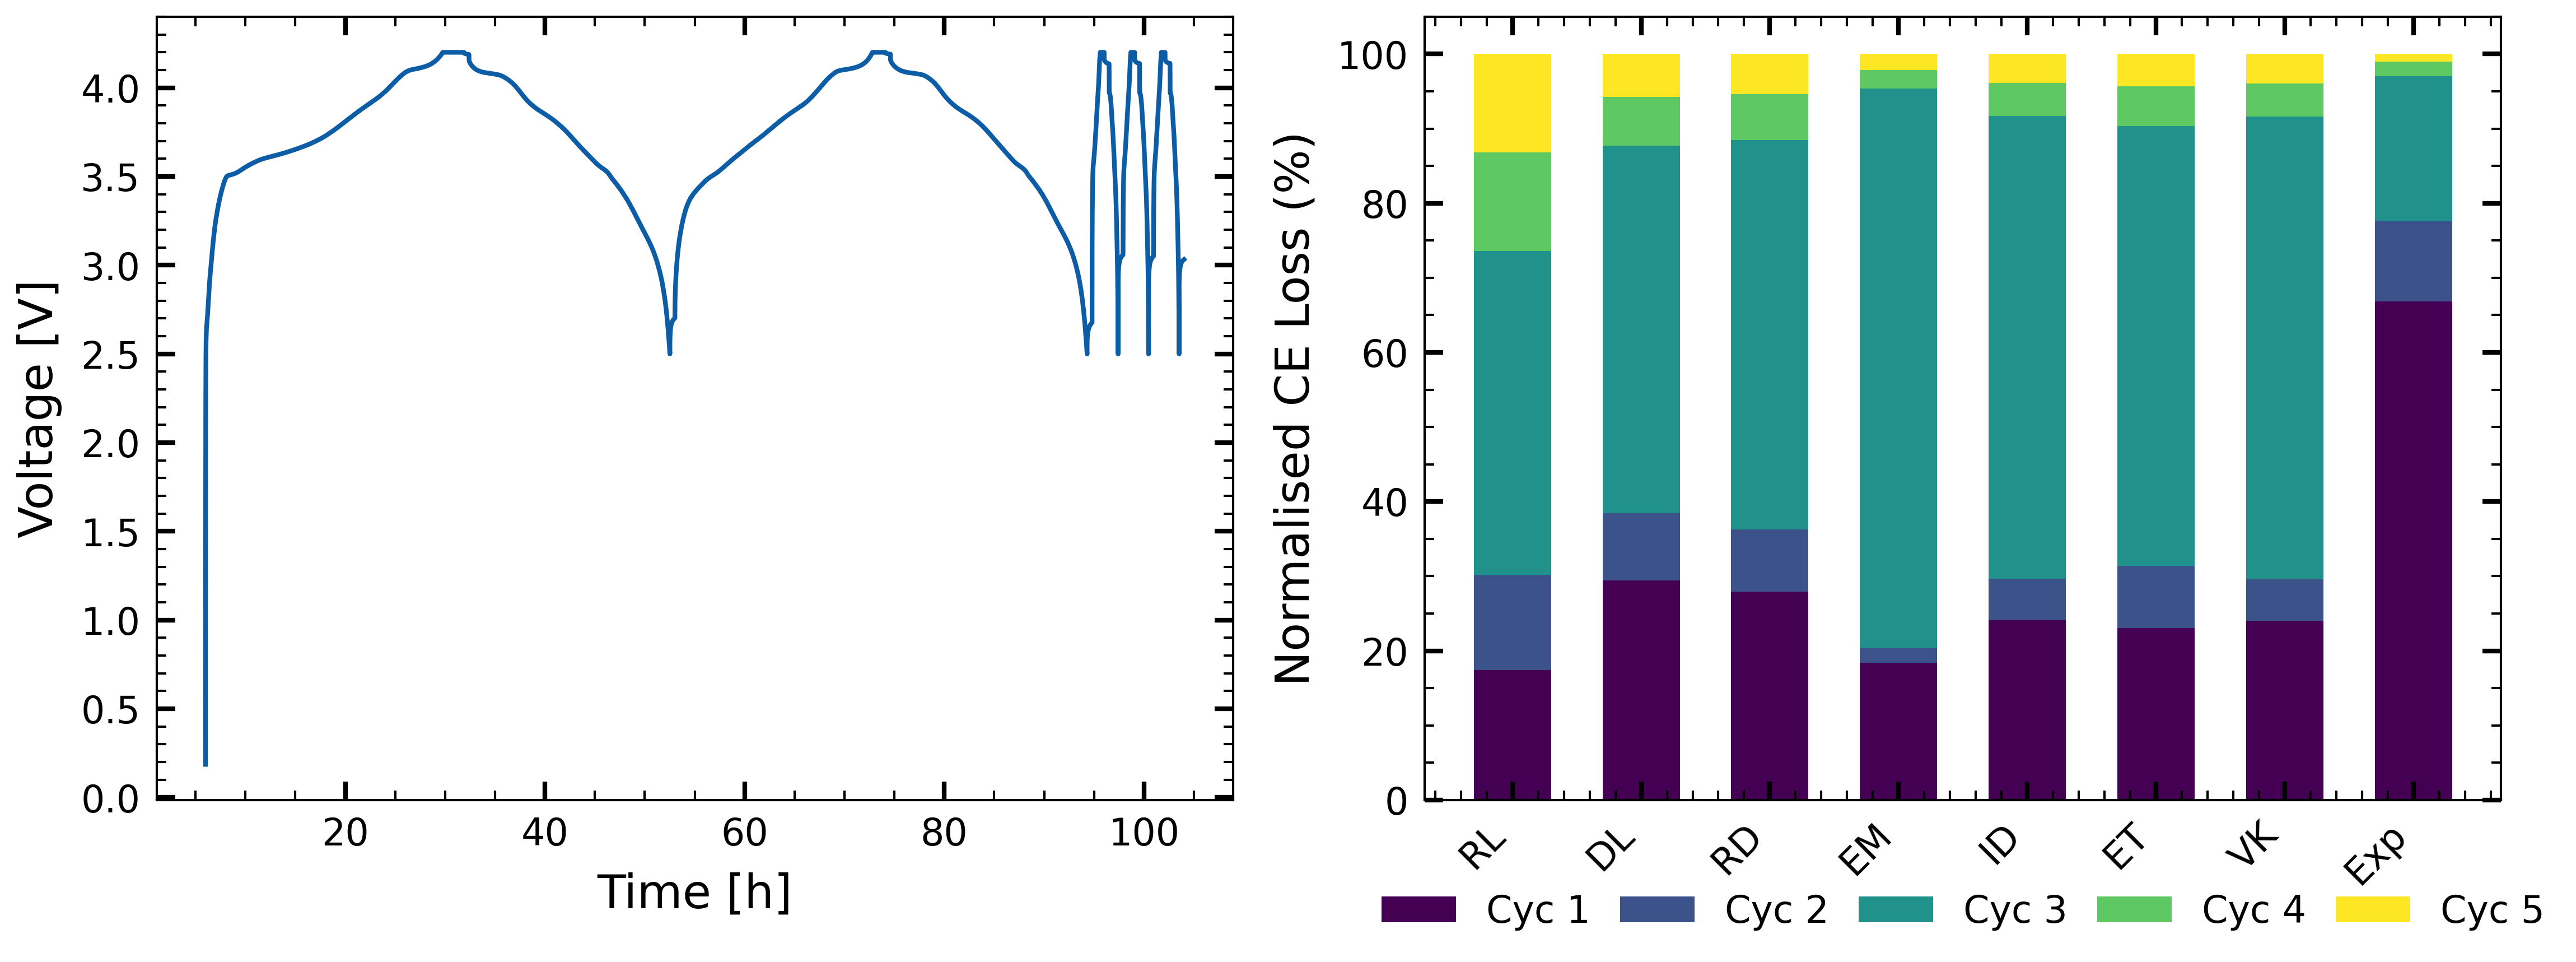

In [4]:
# %cd -
%cd /home/kawamanmi/Projects/formation/comparison_SEI_zero_models
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.ticker as ticker
import numpy as np
from style_figs import set_plotting_format

plt.style.use(['science', 'ieee'])
set_plotting_format("paper")  # input should be either "presentation" or "paper"

models = ["RL", "DL", "RD", "EM", "ID", "ET", "VK", "Exp"]  
cycles = ['Cyc 1', 'Cyc 2', 'Cyc 3', 'Cyc 4', 'Cyc 5']

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

x = np.arange(len(models))
colors = plt.cm.viridis(np.linspace(0, 1, len(cycles)))
bar_width = 0.6  # Adjust this value to make bars thinner or thicker

# Plot for all models
bottom = np.zeros(len(models))
for i, cycle in enumerate(cycles):
    values = [model_data[i] for model_data in all_coulombic_efficiencies]
    
    # Normalize the data
    totals = [sum(model_data) for model_data in all_coulombic_efficiencies]
    normalized_values = [value / total * 100 for value, total in zip(values, totals)]
    
    axes[1].bar(x, normalized_values, bar_width, bottom=bottom, label=cycle, color=colors[i])
    bottom += normalized_values

axes[1].set_ylabel('Normalised CE Loss (%)')
# axes[1].set_xlabel(models)
# axes[1].set_title('Normalized Coulombic Efficiency Loss by Model and Cycle')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend(bbox_to_anchor=(0.5, -0.1),
           loc='upper center',
           ncol=len(cycles),
           borderaxespad=0.,
           columnspacing=0.8)


axes[0].plot(df_combined["time/s"]/3600, df_combined["Ecell/V"], label="Exp")
axes[0].set_xlabel("Time [h]")
axes[0].set_ylabel("Voltage [V]")


plt.tight_layout()
plt.show()

The efficiency loss appears to be fluctuating here. This is because the C-rates in formation cycles are completely different from normal cycling.

In [42]:
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np

c_rate_formation = 20  # Assuming this is defined elsewhere
c_rate_cycling = 1/20


formation_cycle = [
    (f"Charge at C/{c_rate_formation} until 4.2 V"),
    (f"Discharge at C/{c_rate_formation} until 2.5 V"),
]

cycling = [
    f"Charge at {c_rate_cycling}C until 4.2 V",
    f"Discharge at {c_rate_cycling}C until 2.5 V",
]

exp = pybamm.Experiment(
    formation_cycle * 2 +
    cycling * 3
)

# The SEI layer considered as one layer here, 
# so in all equations if there were Outer_or inner they have been removed
sei_options = [ "ec reaction limited", "ec reaction limited", "ec reaction limited",  "electron-migration limited",  "interstitial-diffusion limited", "tunnelling limited" , "Kolzenberg2020" ]
label_sei_options = ["RL", "DL", "Mixed", "EM", "ID", "ET", "VK"]  


k_sei =[ 7.0e-13, 1e-7, 1e-10, 1, 1, 7.0e-13, 1]
D_sol = [1e-14,1e-22, 0.8e-22, 1, 1, 1e-14, 1 ]
params = []
for i in range(0, len(k_sei)):
  param=pybamm.ParameterValues('Chen2020')
  param.update({
    'Initial inner SEI thickness [m]':5e-13,
    'Initial outer SEI thickness [m]':5e-13,
    'SEI kinetic rate constant [m.s-1]':k_sei[i],
    'Outer SEI solvent diffusivity [m2.s-1]':D_sol[i],
    'Bulk solvent concentration [mol.m-3]': 4541.0,
    'Inner SEI electron conductivity [S.m-1]': 8.95e-15, 
    'SEI lithium ion conductivity [S.m-1]': 1.0e-7, 
    'Inner SEI lithium interstitial diffusivity [m2.s-1]': 1e-20, 
    'Lithium interstitial reference concentration [mol.m-3]': 1000,
    }
              )
  params.append(param)
# setup pybamm model to includ SEI models as well
# models = [pybamm.lithium_ion.SPM({"particle": "uniform profile",
#                                   "SEI": sei_option}) for sei_option in sei_options]

models = [pybamm.lithium_ion.SPM({
                                  "SEI": sei_option}) for sei_option in sei_options]


solver = pybamm.CasadiSolver(mode="safe", extra_options_setup={"max_num_steps": 100000})

sims = [pybamm.Simulation(model, parameter_values=params[index],
                          experiment=exp, solver=solver) for index, model in enumerate(models)]
sols = [sim.solve(initial_soc=0) for sim in sims]


/home/kawamanmi/Projects/PyBaMM


In [43]:
%cd /home/kawamanmi/Projects/formation/comparison_SEI_zero_models
import numpy as np

start_cycle = 1  # or whatever cycle number you want to start from


all_model_capacity_loss=[]
for index, model in enumerate(models):
    model_capacity_loss =[]
    for cycle_index in range(start_cycle - 1, len(sols[index].cycles)-1, 2):
        time_ch = sols[index].cycles[cycle_index]["Time [s]"].entries 
        time_dch = sols[index].cycles[cycle_index + 1]["Time [s]"].entries
        ch_cacpacity_loss = sols[index].cycles[cycle_index]['Total capacity lost to side reactions [A.h]'](time_ch[-1]) - \
                            sols[index].cycles[cycle_index]['Total capacity lost to side reactions [A.h]'](time_ch[0])
        dch_cacpacity_loss = sols[index].cycles[cycle_index + 1]['Total capacity lost to side reactions [A.h]'](time_dch[-1]) - \
                            sols[index].cycles[cycle_index + 1]['Total capacity lost to side reactions [A.h]'](time_dch[0]) 
        model_capacity_loss.append((ch_cacpacity_loss + dch_cacpacity_loss))
    all_model_capacity_loss.append( model_capacity_loss)

/home/kawamanmi/Projects/formation/comparison_SEI_zero_models


/home/kawamanmi/Projects/formation/comparison_SEI_zero_models


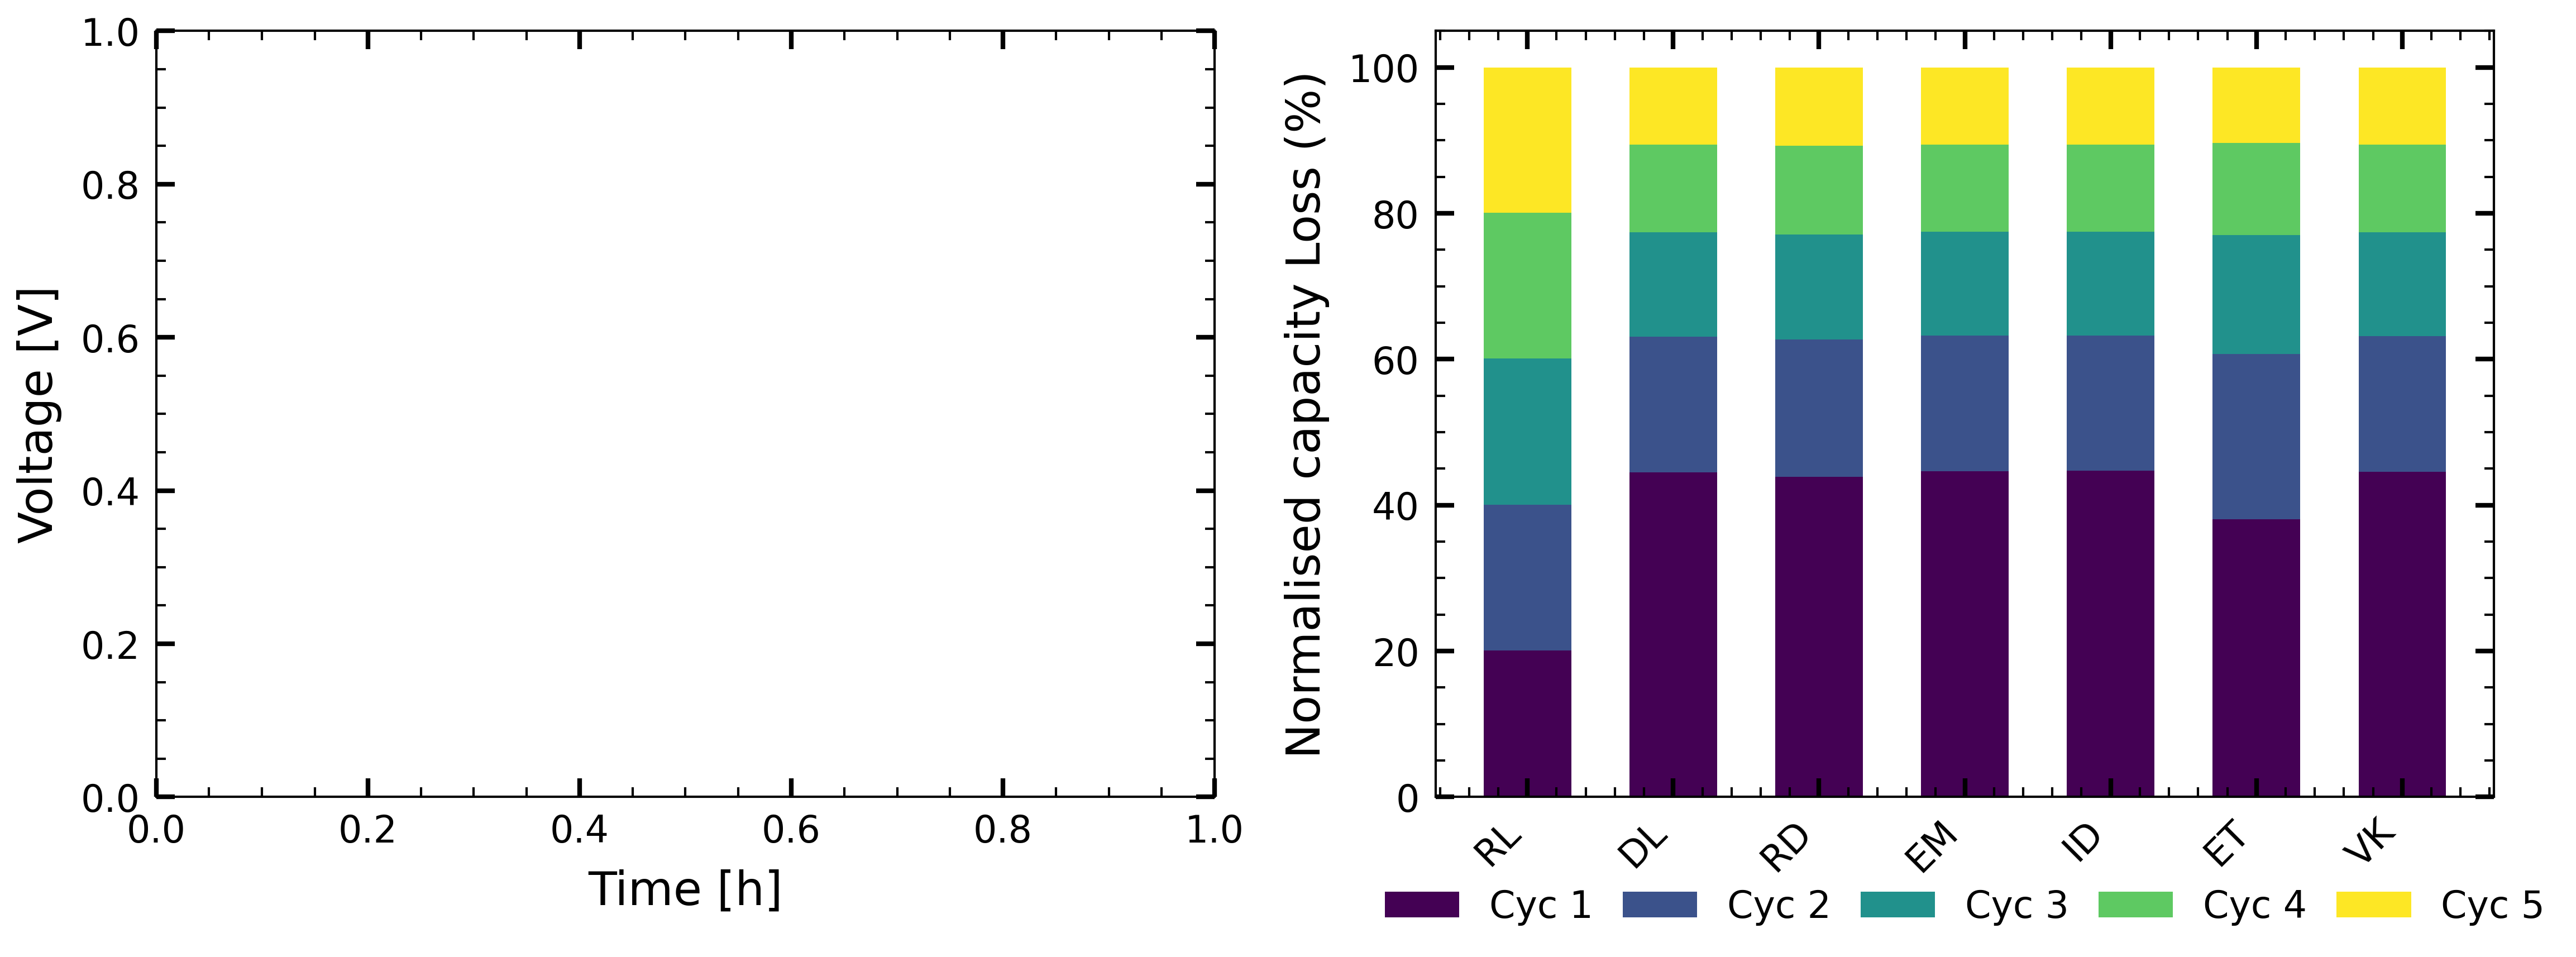

In [44]:
# %cd -
%cd /home/kawamanmi/Projects/formation/comparison_SEI_zero_models
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.ticker as ticker
import numpy as np
from style_figs import set_plotting_format

plt.style.use(['science', 'ieee'])
set_plotting_format("paper")  # input should be either "presentation" or "paper"

models = ["RL", "DL", "RD", "EM", "ID", "ET", "VK"]  
cycles = ['Cyc 1', 'Cyc 2', 'Cyc 3', 'Cyc 4', 'Cyc 5']

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

x = np.arange(len(models))
colors = plt.cm.viridis(np.linspace(0, 1, len(cycles)))
bar_width = 0.6  # Adjust this value to make bars thinner or thicker

# Plot for all models
bottom = np.zeros(len(models))
for i, cycle in enumerate(cycles):
    values = [model_data[i] for model_data in all_model_capacity_loss]
    
    # Normalize the data
    totals = [sum(model_data) for model_data in all_model_capacity_loss]
    normalized_values = [value / total * 100 for value, total in zip(values, totals)]
    
    axes[1].bar(x, normalized_values, bar_width, bottom=bottom, label=cycle, color=colors[i])
    bottom += normalized_values

axes[1].set_ylabel('Normalised capacity Loss (%)')
# axes[1].set_xlabel(models)
# axes[1].set_title('Normalized Coulombic Efficiency Loss by Model and Cycle')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend(bbox_to_anchor=(0.5, -0.1),
           loc='upper center',
           ncol=len(cycles),
           borderaxespad=0.,
           columnspacing=0.8)


# axes[0].plot(df_combined["time/s"]/3600, df_combined["Ecell/V"], label="Exp")
axes[0].set_xlabel("Time [h]")
axes[0].set_ylabel("Voltage [V]")


plt.tight_layout()
plt.show()

In [39]:
# Rate for formation cycle much less than cycling  below
%cd /home/kawamanmi/Projects/PyBaMM
import pybamm
import numpy as np

c_rate_formation = 20  # Assuming this is defined elsewhere
c_rate_cycling = 1


formation_cycle = [
    (f"Charge at C/{c_rate_formation} until 4.2 V"),
    (f"Discharge at C/{c_rate_formation} until 2.5 V"),
]

cycling = [
    f"Charge at {c_rate_cycling}C until 4.2 V",
    f"Discharge at {c_rate_cycling}C until 2.5 V",
]

exp = pybamm.Experiment(
    formation_cycle * 2 +
    cycling * 3
)

# The SEI layer considered as one layer here, 
# so in all equations if there were Outer_or inner they have been removed
sei_options = [ "ec reaction limited", "ec reaction limited", "ec reaction limited",  "electron-migration limited",  "interstitial-diffusion limited", "tunnelling limited" , "Kolzenberg2020" ]
label_sei_options = ["RL", "DL", "Mixed", "EM", "ID", "ET", "VK"]  


k_sei =[ 7.0e-13, 1e-7, 1e-10, 1, 1, 7.0e-13, 1]
D_sol = [1e-14,1e-22, 0.8e-22, 1, 1, 1e-14, 1 ]
params = []
for i in range(0, len(k_sei)):
  param=pybamm.ParameterValues('Chen2020')
  param.update({
    'Initial inner SEI thickness [m]':5e-13,
    'Initial outer SEI thickness [m]':5e-13,
    'SEI kinetic rate constant [m.s-1]':k_sei[i],
    'Outer SEI solvent diffusivity [m2.s-1]':D_sol[i],
    'Bulk solvent concentration [mol.m-3]': 4541.0,
    'Inner SEI electron conductivity [S.m-1]': 8.95e-15, 
    'SEI lithium ion conductivity [S.m-1]': 1.0e-7, 
    'Inner SEI lithium interstitial diffusivity [m2.s-1]': 1e-20, 
    'Lithium interstitial reference concentration [mol.m-3]': 1000,
    }
              )
  params.append(param)
# setup pybamm model to includ SEI models as well
# models = [pybamm.lithium_ion.SPM({"particle": "uniform profile",
#                                   "SEI": sei_option}) for sei_option in sei_options]

models = [pybamm.lithium_ion.SPM({
                                  "SEI": sei_option}) for sei_option in sei_options]


solver = pybamm.CasadiSolver(mode="safe", extra_options_setup={"max_num_steps": 100000})

sims = [pybamm.Simulation(model, parameter_values=params[index],
                          experiment=exp, solver=solver) for index, model in enumerate(models)]
sols = [sim.solve(initial_soc=0) for sim in sims]


/home/kawamanmi/Projects/PyBaMM


At t = 231.896 and h = 0.000766502, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 231.896 and h = 3.09146e-05, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 231.912 and h = 0.000766607, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 231.912 and h = 3.08514e-05, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 231.911 and h = 0.000766612, the corrector convergence test failed repeatedly or with |h| = hmin.
At t = 231.911 and h = 3.08566e-05, the corrector convergence test failed repeatedly or with |h| = hmin.


In [45]:
%cd /home/kawamanmi/Projects/formation/comparison_SEI_zero_models
import numpy as np


start_cycle = 1  # or whatever cycle number you want to start from

all_model_capacity_loss=[]
for index, model in enumerate(models):
    model_capacity_loss =[]
    for cycle_index in range(start_cycle - 1, len(sols[index].cycles)-1, 2):
        time_ch = sols[index].cycles[cycle_index]["Time [s]"].entries 
        time_dch = sols[index].cycles[cycle_index + 1]["Time [s]"].entries
        ch_cacpacity_loss = sols[index].cycles[cycle_index]['Total capacity lost to side reactions [A.h]'](time_ch[-1]) - \
                            sols[index].cycles[cycle_index]['Total capacity lost to side reactions [A.h]'](time_ch[0])
        dch_cacpacity_loss = sols[index].cycles[cycle_index + 1]['Total capacity lost to side reactions [A.h]'](time_dch[-1]) - \
                            sols[index].cycles[cycle_index + 1]['Total capacity lost to side reactions [A.h]'](time_dch[0]) 
        model_capacity_loss.append((ch_cacpacity_loss + dch_cacpacity_loss))
    all_model_capacity_loss.append(model_capacity_loss)

/home/kawamanmi/Projects/formation/comparison_SEI_zero_models


/home/kawamanmi/Projects/formation/comparison_SEI_zero_models


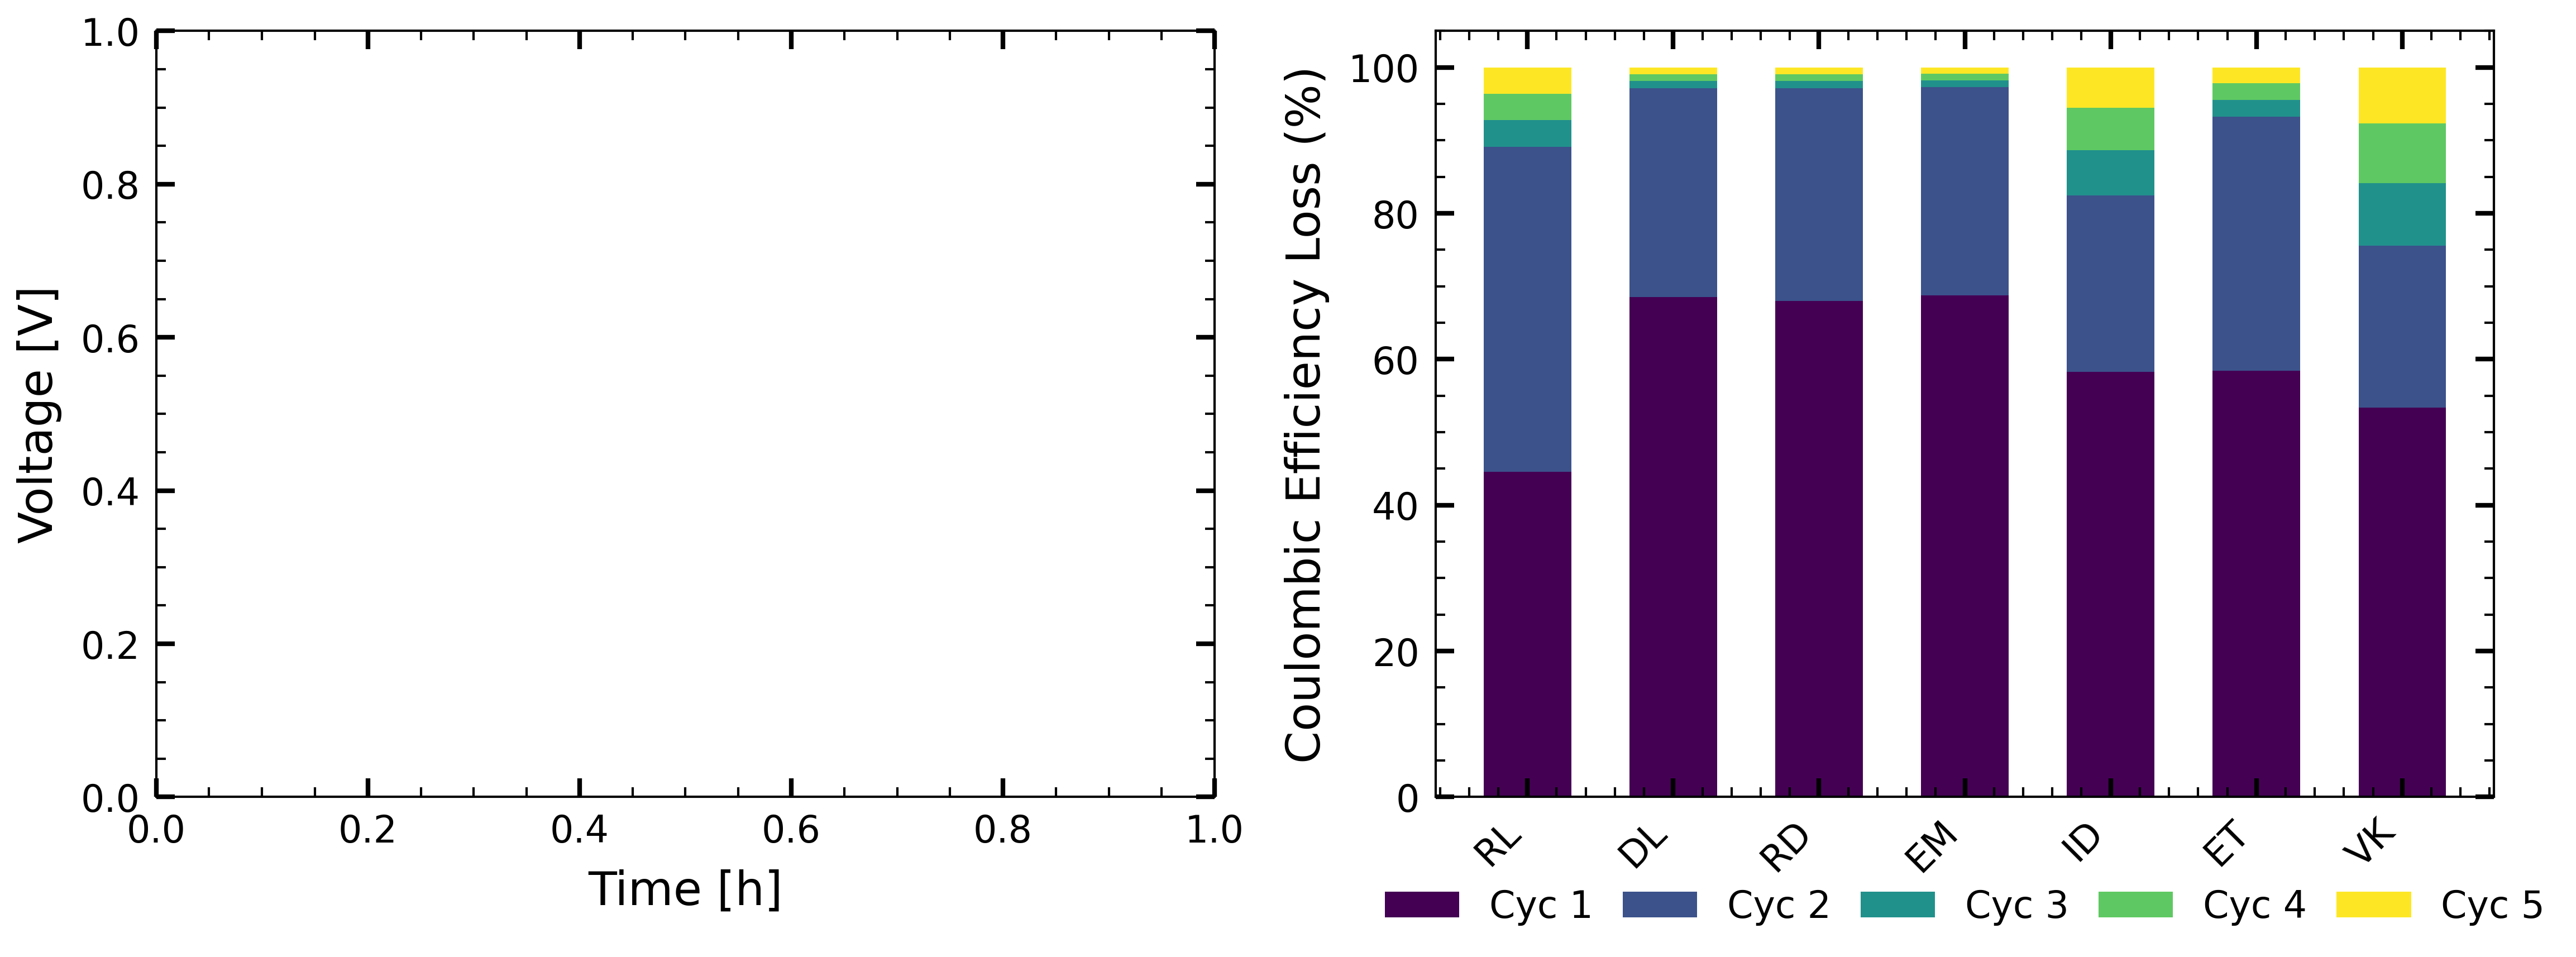

In [46]:
# %cd -
%cd /home/kawamanmi/Projects/formation/comparison_SEI_zero_models
import matplotlib.pyplot as plt
import scienceplots
import matplotlib.ticker as ticker
import numpy as np
from style_figs import set_plotting_format

plt.style.use(['science', 'ieee'])
set_plotting_format("paper")  # input should be either "presentation" or "paper"

models = ["RL", "DL", "RD", "EM", "ID", "ET", "VK"]  
cycles = ['Cyc 1', 'Cyc 2', 'Cyc 3', 'Cyc 4', 'Cyc 5']

fig, axes = plt.subplots(1, 2, figsize=(8, 3))

x = np.arange(len(models))
colors = plt.cm.viridis(np.linspace(0, 1, len(cycles)))
bar_width = 0.6  # Adjust this value to make bars thinner or thicker

# Plot for all models
bottom = np.zeros(len(models))
for i, cycle in enumerate(cycles):
    values = [model_data[i] for model_data in all_coulombic_efficiencies]
    
    # Normalize the data
    totals = [sum(model_data) for model_data in all_coulombic_efficiencies]
    normalized_values = [value / total * 100 for value, total in zip(values, totals)]
    
    axes[1].bar(x, normalized_values, bar_width, bottom=bottom, label=cycle, color=colors[i])
    bottom += normalized_values

axes[1].set_ylabel('Coulombic Efficiency Loss (%)')
# axes[1].set_xlabel(models)
# axes[1].set_title('Normalized Coulombic Efficiency Loss by Model and Cycle')
axes[1].set_xticks(x)
axes[1].set_xticklabels(models, rotation=45, ha='right')
axes[1].legend(bbox_to_anchor=(0.5, -0.1),
           loc='upper center',
           ncol=len(cycles),
           borderaxespad=0.,
           columnspacing=0.8)


# axes[0].plot(df_combined["time/s"]/3600, df_combined["Ecell/V"], label="Exp")
axes[0].set_xlabel("Time [h]")
axes[0].set_ylabel("Voltage [V]")


plt.tight_layout()
plt.show()